# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset and perform operations 

In [2]:
df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("df.dtypes: ", df.dtypes)
df.isnull().sum()


df:        Year             Company    Industry Country Company_Type Employee_Size  \
0     2020              Amazon  E-commerce     USA         Real    Enterprise   
1     2021              Amazon  E-commerce     USA         Real    Enterprise   
2     2022              Amazon  E-commerce     USA         Real    Enterprise   
3     2023              Amazon  E-commerce     USA         Real    Enterprise   
4     2024              Amazon  E-commerce     USA         Real    Enterprise   
...    ...                 ...         ...     ...          ...           ...   
5995  2021  SyntheticCorp_0980     Telecom  Brazil    Synthetic    Enterprise   
5996  2022  SyntheticCorp_0980     Finance   India    Synthetic           SME   
5997  2023  SyntheticCorp_0980  Technology  Canada    Synthetic    Enterprise   
5998  2024  SyntheticCorp_0980   Logistics     UAE    Synthetic    Enterprise   
5999  2025  SyntheticCorp_0980  Healthcare   Japan    Synthetic           SME   

       Revenue_USD Use

Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64

# Seaborn Graphs 

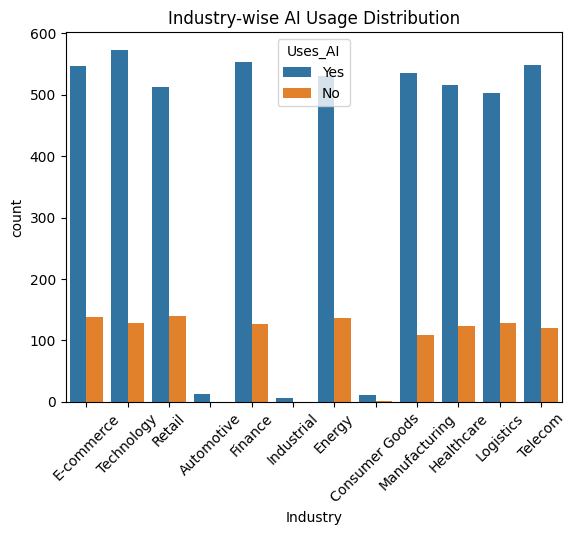

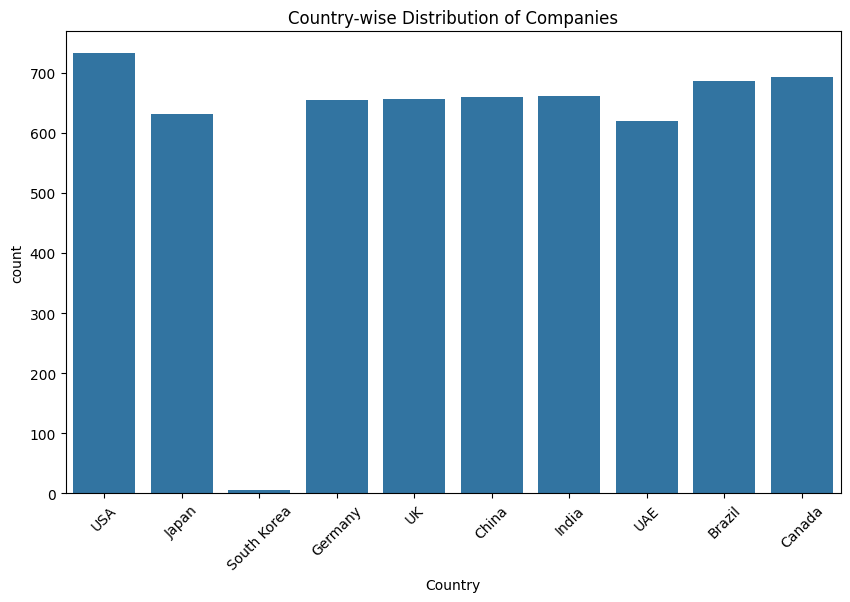

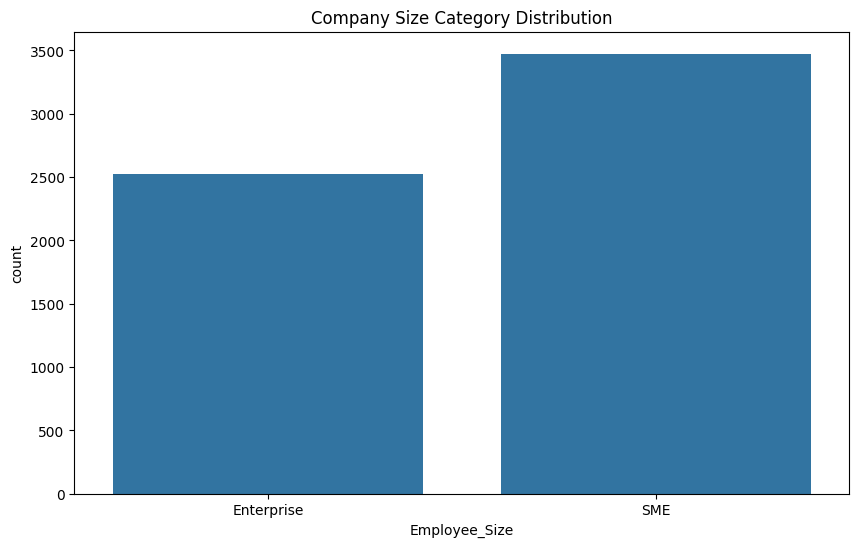

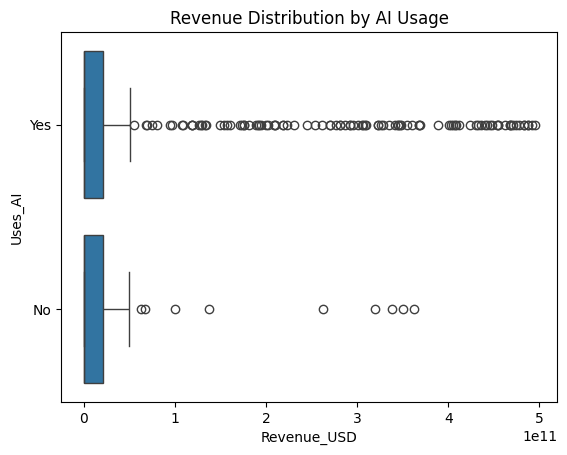

In [ ]:
#countplot for Industry with AI usage 
sns.countplot(x='Industry', hue='Uses_AI', data=df)
plt.xticks(rotation=45)
plt.title('Industry-wise AI Usage Distribution')
plt.show()

#counplot for countrywise distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Country', data=df)
plt.xticks(rotation=45)
plt.title('Country-wise Distribution of Companies')
plt.show()

# countplot for Employee Size distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Employee_Size', data=df)
plt.title('Company Size Category Distribution')
plt.show()

# Boxplot for Revenue vs AI Usage 
sns.boxplot(x='Revenue_USD', y='Uses_AI', data=df)
plt.title('Revenue Distribution by AI Usage')
plt.show()

# Feature Selection

In [9]:
cols_to_drop = ['Use_Case', 'Company_Type', 'Employee_Size','Company','AI_ROI_Percent', 'AI_Maturity_Score']
df = df.drop(columns= cols_to_drop, errors='ignore')

X = df[['Year', 'Revenue_USD','Industry','Country']]
y = df['Uses_AI']

print("X:", X)
print("y:", y)

X:       Year   Revenue_USD    Industry Country
0     2020  4.535464e+11  E-commerce     USA
1     2021  4.878035e+11  E-commerce     USA
2     2022  2.182500e+11  E-commerce     USA
3     2023  4.114132e+11  E-commerce     USA
4     2024  3.191970e+11  E-commerce     USA
...    ...           ...         ...     ...
5995  2021  1.398673e+10     Telecom  Brazil
5996  2022  2.847901e+07     Finance   India
5997  2023  3.516618e+10  Technology  Canada
5998  2024  2.835842e+10   Logistics     UAE
5999  2025  1.678214e+07  Healthcare   Japan

[6000 rows x 4 columns]
y: 0       Yes
1       Yes
2       Yes
3       Yes
4        No
       ... 
5995     No
5996    Yes
5997     No
5998    Yes
5999    Yes
Name: Uses_AI, Length: 6000, dtype: object


# Apply Encoding for company,country, industry

In [10]:
from sklearn.preprocessing import OneHotEncoder
categorical_cols = ['Industry', 'Country']


X = df.drop(columns=['Uses_AI'])

ohe = OneHotEncoder(sparse_output=False, drop='first')

ohe_array = ohe.fit_transform(X[categorical_cols])
print("OHE feature names:", ohe.get_feature_names_out(categorical_cols))

ohe_df = pd.DataFrame(
    ohe_array, columns=ohe.get_feature_names_out(categorical_cols))

# Drop original categorical columns
X = X.drop(columns=categorical_cols)

df_ohe = pd.concat([X.reset_index(drop=True), ohe_df.reset_index(drop=True)], axis=1)
print(df_ohe.head())

print(df_ohe.dtypes)

OHE feature names: ['Industry_Consumer Goods' 'Industry_E-commerce' 'Industry_Energy'
 'Industry_Finance' 'Industry_Healthcare' 'Industry_Industrial'
 'Industry_Logistics' 'Industry_Manufacturing' 'Industry_Retail'
 'Industry_Technology' 'Industry_Telecom' 'Country_Canada' 'Country_China'
 'Country_Germany' 'Country_India' 'Country_Japan' 'Country_South Korea'
 'Country_UAE' 'Country_UK' 'Country_USA']
   Year   Revenue_USD  Industry_Consumer Goods  Industry_E-commerce  \
0  2020  4.535464e+11                      0.0                  1.0   
1  2021  4.878035e+11                      0.0                  1.0   
2  2022  2.182500e+11                      0.0                  1.0   
3  2023  4.114132e+11                      0.0                  1.0   
4  2024  3.191970e+11                      0.0                  1.0   

   Industry_Energy  Industry_Finance  Industry_Healthcare  \
0              0.0               0.0                  0.0   
1              0.0               0.0         

# Applied Train Test Split Function

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=42,stratify=y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models applied 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,accuracy_score

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("Logistic Regression:\n", classification_report(y_test, lr_preds))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
print("KNN:\n", classification_report(y_test, knn_preds))




Logistic Regression:
               precision    recall  f1-score   support

          No       0.18      0.63      0.28       230
         Yes       0.78      0.32      0.45       970

    accuracy                           0.38      1200
   macro avg       0.48      0.48      0.37      1200
weighted avg       0.67      0.38      0.42      1200

KNN:
               precision    recall  f1-score   support

          No       0.20      0.04      0.07       230
         Yes       0.81      0.96      0.88       970

    accuracy                           0.78      1200
   macro avg       0.50      0.50      0.47      1200
weighted avg       0.69      0.78      0.72      1200



# Analysis

In [ ]:
#No, real accuracy is not possible with this dataset for any classification problem
#The features AI_ROI_Percent and AI_Maturiy score has direct realtionship with Uses_AI column
#Any other feature like Country,Industry,Year,Revenue_USD has weak relationship or zero with the target column
#Use_Case — randomly rotated per company per year, even Amazon changes use case every year which is unrealistic.